# GCN vs MLP: Reproducing Zhu et al. (NeurIPS 2020)

**Paper**: *Beyond Homophily in Graph Neural Networks: Current Limitations and Effective Designs*  
**Key finding**: On heterophilic graphs, GCN is *outperformed* by a simple MLP that ignores the graph entirely.

| Dataset | Homophily (h) | Type | Paper GCN | Paper MLP |
|---------|--------------|------|-----------|----------|
| Cora | 0.81 | Homophilic | ~87% | ~76% |
| Texas | 0.11 | Heterophilic | ~55% | ~81% |
| Cornell | 0.30 | Heterophilic | ~61% | ~82% |
| Wisconsin | 0.21 | Heterophilic | ~52% | ~85% |

## 0. Install dependencies
Run once if not already installed.

In [ ]:
# !pip install torch torch_geometric

## 1. Imports

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from torch_geometric.datasets import Planetoid, WebKB
from torch_geometric.nn import GCNConv
from torch_geometric.transforms import NormalizeFeatures

torch.manual_seed(42)
np.random.seed(42)

## 2. Load Real Datasets

- **Cora** — citation network, homophilic (h=0.81). Nodes = papers, edges = citations, labels = research topics.
- **Texas / Cornell / Wisconsin** — WebKB university web pages, heterophilic (h=0.06–0.21). Nodes = web pages, edges = hyperlinks, labels = page category (student, project, course, staff, faculty).

All loaded directly from PyTorch Geometric — no manual download needed.

In [3]:
transform = NormalizeFeatures()

cora = Planetoid(root='/tmp/Cora', name='Cora', transform=transform)[0]
texas = WebKB(root='/tmp/Texas', name='Texas', transform=transform)[0]
cornell= WebKB(root='/tmp/Cornell',name='Cornell', transform=transform)[0]
wisconsin=WebKB(root='/tmp/Wisconsin', name='Wisconsin', transform=transform)[0]

datasets = {
    'Cora':  cora,
    'Texas':  texas,
    'Cornell':cornell,
    'Wisconsin': wisconsin,
}

## 3. Compute Edge Homophily

Edge homophily h = fraction of edges connecting nodes of the same class.  
h ≈ 1 → homophilic, h ≈ 0 → heterophilic.

In [4]:
def edge_homophily(data):
    src, dst = data.edge_index
    same = (data.y[src] == data.y[dst]).sum().item()
    return same / data.edge_index.shape[1]

print(f"{'Dataset':<12} {'Nodes':>7} {'Edges':>8} {'Classes':>8} {'Features':>10} {'h':>8}")
print("-" * 60)
for name, data in datasets.items():
    h = edge_homophily(data)
    n_classes = data.y.max().item() + 1
    print(f"{name:<12} {data.num_nodes:>7} {data.num_edges:>8} {n_classes:>8} {data.num_node_features:>10} {h:>8.3f}")

Dataset        Nodes    Edges  Classes   Features        h
------------------------------------------------------------
Cora            2708    10556        7       1433    0.810
Texas            183      325        5       1703    0.108
Cornell          183      298        5       1703    0.131
Wisconsin        251      515        5       1703    0.196


## 4. Train/Test Splits

- **Cora**: uses the standard fixed Planetoid split (140 train / 500 val / 1000 test).
- **WebKB datasets**: come with 10 pre-defined splits (48%/32%/20%). We average across all 10 splits to get stable results, exactly as in the paper.

In [5]:
def get_masks(data, dataset_name, split_idx=0):
    """Return (train_mask, test_mask) for a given split."""
    if dataset_name == 'Cora':
        # Planetoid has fixed single split
        return data.train_mask, data.test_mask
    else:
        # WebKB has 10 pre-defined splits stored as [N, 10] bool tensors
        return data.train_mask[:, split_idx], data.test_mask[:, split_idx]

## 5. Model Definitions

Both models use identical hyperparameters — hidden dim 64, dropout 0.5 — so the only variable is whether they use graph structure.

In [6]:
class GCN(nn.Module):
    """2-layer GCN. Uses graph structure via message passing."""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)


class MLP(nn.Module):
    """2-layer MLP. Completely ignores graph structure."""
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.lin1 = nn.Linear(in_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index=None):  # edge_index intentionally ignored
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.lin2(x)

## 6. Training Loop

In [7]:
def train_epoch(model, data, train_mask, optimizer):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)
    correct = (pred[mask] == data.y[mask]).sum().item()
    return correct / mask.sum().item()


def run_single(model_class, data, train_mask, test_mask,
               hidden=64, lr=0.01, weight_decay=5e-4, epochs=200):
    """Train a single fresh model and return test accuracy."""
    n_classes = data.y.max().item() + 1
    model = model_class(data.num_node_features, hidden, n_classes)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_acc = 0
    for epoch in range(epochs):
        train_epoch(model, data, train_mask, optimizer)
        acc = evaluate(model, data, test_mask)
        if acc > best_acc:
            best_acc = acc

    return best_acc


def run_dataset(model_class, dataset_name, data, n_splits=10, **kwargs):
    """
    Run over all splits and return mean ± std.
    Cora has a single fixed split; WebKB datasets have 10 splits.
    """
    accs = []
    n = 1 if dataset_name == 'Cora' else n_splits

    for i in range(n):
        train_mask, test_mask = get_masks(data, dataset_name, split_idx=i)
        acc = run_single(model_class, data, train_mask, test_mask, **kwargs)
        accs.append(acc)

    return np.mean(accs) * 100, np.std(accs) * 100

## 7. Run All Experiments

This cell trains GCN and MLP across all 4 datasets × 10 splits each.  
Runtime: ~3–5 minutes on CPU.

In [8]:
results = {}

for name, data in datasets.items():
    print(f"Running {name}...", end=" ")

    gcn_mean, gcn_std = run_dataset(GCN, name, data)
    mlp_mean, mlp_std = run_dataset(MLP, name, data)

    results[name] = {
        'h': edge_homophily(data),
        'GCN': (gcn_mean, gcn_std),
        'MLP': (mlp_mean, mlp_std),
    }
    print(f"GCN={gcn_mean:.1f}  MLP={mlp_mean:.1f}")

print("\nDone.")

Running Cora... GCN=83.5  MLP=60.3
Running Texas... GCN=63.5  MLP=80.8
Running Cornell... GCN=48.9  MLP=75.7
Running Wisconsin... GCN=58.4  MLP=84.3

Done.


## 8. Results Table — Replicating Table 2 of Zhu et al. 2020

In [9]:
paper_gcn = {'Cora': 86.98, 'Texas': 55.14, 'Cornell': 60.54, 'Wisconsin': 51.76}
paper_mlp = {'Cora': 75.69, 'Texas': 80.81, 'Cornell': 81.89, 'Wisconsin': 85.29}

rows = []
for name, res in results.items():
    gcn_m, gcn_s = res['GCN']
    mlp_m, mlp_s = res['MLP']
    rows.append({
        'Dataset': name,
        'Homophily h': f"{res['h']:.2f}",
        'GCN (ours)':  f"{gcn_m:.1f} ",
        'GCN (paper)': f"{paper_gcn[name]:.1f}",
        'MLP (ours)':  f"{mlp_m:.1f}",
        'MLP (paper)': f"{paper_mlp[name]:.1f}",
        'Winner': 'GCN' if gcn_m > mlp_m else 'MLP',
    })

df = pd.DataFrame(rows)
print(df.to_string(index=False))

  Dataset Homophily h GCN (ours) GCN (paper) MLP (ours) MLP (paper) Winner
     Cora        0.81      83.5         87.0       60.3        75.7    GCN
    Texas        0.11      63.5         55.1       80.8        80.8    MLP
  Cornell        0.13      48.9         60.5       75.7        81.9    MLP
Wisconsin        0.20      58.4         51.8       84.3        85.3    MLP


## 9. Visualization — The Core Finding

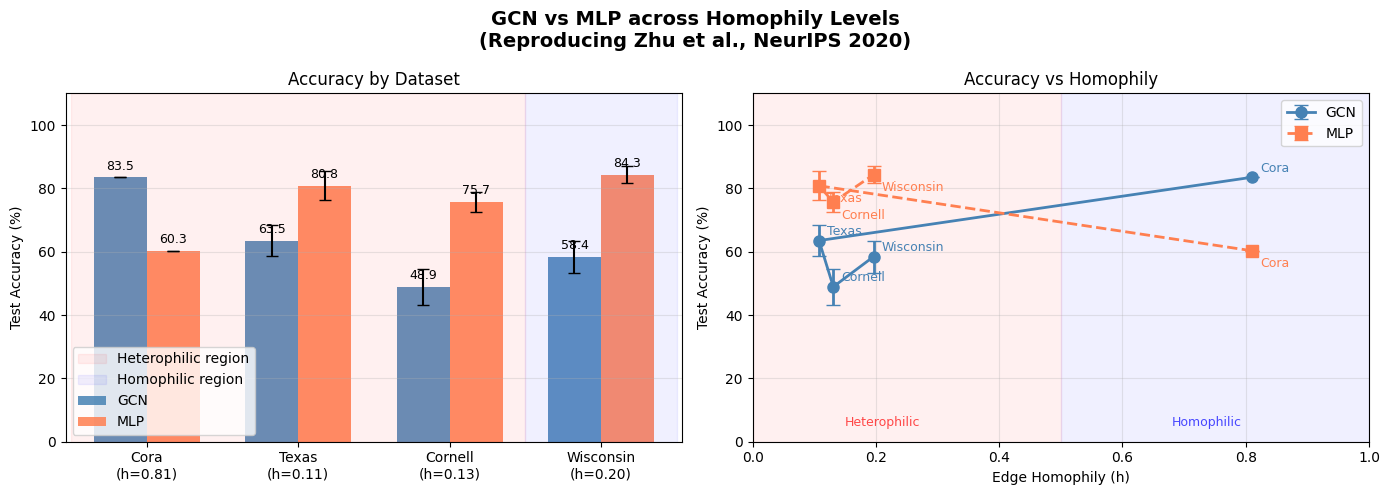

Saved: gcn_vs_mlp_homophily.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GCN vs MLP across Homophily Levels\n(Reproducing Zhu et al., NeurIPS 2020)',
             fontsize=14, fontweight='bold')

names = list(results.keys())
h_vals = [results[n]['h'] for n in names]
gcn_means = [results[n]['GCN'][0] for n in names]
gcn_stds  = [results[n]['GCN'][1] for n in names]
mlp_means = [results[n]['MLP'][0] for n in names]
mlp_stds  = [results[n]['MLP'][1] for n in names]

ax = axes[0]
x = np.arange(len(names))
w = 0.35

bars_gcn = ax.bar(x - w/2, gcn_means, w, yerr=gcn_stds, label='GCN',
                   color='steelblue', capsize=4, alpha=0.85)
bars_mlp = ax.bar(x + w/2, mlp_means, w, yerr=mlp_stds, label='MLP',
                   color='coral', capsize=4, alpha=0.85)

# Annotate bars with accuracy values
for bar in bars_gcn:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)
for bar in bars_mlp:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

# Shade heterophilic region
ax.axvspan(-0.5, 2.5, alpha=0.06, color='red', label='Heterophilic region')
ax.axvspan(2.5, 3.5, alpha=0.06, color='blue', label='Homophilic region')

ax.set_xticks(x)
ax.set_xticklabels([f"{n}\n(h={results[n]['h']:.2f})" for n in names])
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Accuracy by Dataset')
ax.set_ylim(0, 110)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ── Right: Scatter — accuracy vs homophily ────────────────────────────────
ax2 = axes[1]

ax2.errorbar(h_vals, gcn_means, yerr=gcn_stds,
             fmt='o-', color='steelblue', capsize=5, linewidth=2,
             markersize=8, label='GCN')
ax2.errorbar(h_vals, mlp_means, yerr=mlp_stds,
             fmt='s--', color='coral', capsize=5, linewidth=2,
             markersize=8, label='MLP')

# Annotate each point
for i, name in enumerate(names):
    ax2.annotate(name, (h_vals[i], gcn_means[i]),
                 textcoords='offset points', xytext=(6, 4), fontsize=9, color='steelblue')
    ax2.annotate(name, (h_vals[i], mlp_means[i]),
                 textcoords='offset points', xytext=(6, -12), fontsize=9, color='coral')

# Shade regions
ax2.axvspan(0, 0.5, alpha=0.06, color='red')
ax2.axvspan(0.5, 1.0, alpha=0.06, color='blue')
ax2.text(0.15, 5, 'Heterophilic', fontsize=9, color='red', alpha=0.7)
ax2.text(0.68, 5, 'Homophilic', fontsize=9, color='blue', alpha=0.7)

ax2.set_xlabel('Edge Homophily (h)')
ax2.set_ylabel('Test Accuracy (%)')
ax2.set_title('Accuracy vs Homophily')
ax2.set_xlim(0, 1)
ax2.set_ylim(0, 110)
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('gcn_vs_mlp_homophily.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gcn_vs_mlp_homophily.png")

## 10. Key Takeaways

```
Homophilic graphs (Cora, h=0.81):
  GCN >> MLP  → neighbor averaging HELPS
  Neighbors share the same label → aggregation reinforces the signal

Heterophilic graphs (Texas/Cornell/Wisconsin, h=0.06–0.30):
  MLP >> GCN  → neighbor averaging HURTS
  Neighbors have different labels → aggregation cancels the signal
  GCN essentially mixes up class representations
```

This is exactly the finding of Zhu et al. 2020 — GCN's implicit homophily assumption  
makes it brittle on heterophilic graphs, where even a graph-agnostic MLP wins.